In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


## Train Dataset

In [2]:
df_source1 = pd.read_csv("../../dataset/student_resource/dataset/train/train_source1.tsv" , sep = "\t")
df_source2 = pd.read_csv("../../dataset/student_resource/dataset/train/train_source2.tsv" , sep = "\t")
df_source3 = pd.read_csv("../../dataset/student_resource/dataset/train/train_source3.tsv" , sep = "\t")
train_ground_truth = pd.read_csv("../../dataset/student_resource/dataset/train/train_ground_truth.tsv" , sep = "\t")

In [3]:
df_source1.head(50)

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India
5,S1-851869949,Custom Wealth Services LLC,"OH, Columbus, 5559 Orville Avenue",US
6,S1-785847572,Consulting Nyasa Nursing Private Limited,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",India
7,S1-27541239,Nexus Anchor Rain,"1111 Church Street, Unit 2007, Nashville, TN",US
8,S1-629417405,Moore Bitwise Inc,"337 Oakland Avenue, Michigan City, IN",US
9,S1-22305073,Dermatology Green Medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",US


In [4]:
df_source2.head(20)

,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US
5,S2-138046867,Lee and Lawson,"1702 Pine Avenue, CITY OF MENOMONIE, WI",US
6,S2-584977605,SHIVSHAKTI VIDYALAYA VIDYALAYA OVERSEAS CORPOR...,"H.NO 204 C ROAD HOSHIARPUR, PUNJAB, Punjab",India
7,S2-277444929,Shree Infracon Private Ltd,"63/2275/7, ALHIND TOWER, FIRST FLOOR, JAFFERKH...",India
8,S2-721031885,Chavira Platinum Chimera LLC,"282 SAXONY DRIVE, FTT MITCHELL, KY",US
9,S2-508602797,FOUNDATION EXCEL AGENCY PRIVATE LIMITED,"HN 753 E-1, BHARAT NAGAR, 104/1/1 ERANDWANE, M...",India


In [5]:
df_source3.head(20)

,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India
5,S3-578159284,LLC Hernandez Colonial Redwood,"2260- Housecreek Trail, Unit 407, Raleigh, Nor...",US
6,S3-121412624,Classic Equity Partners Group,"6885 Catalpa Bluff Ln, PO Box 5799, Dickinson,...",US
7,S3-249416830,Ectolumdrex dba X+ Madison Inc,"S03575 Cty Tk M, Town Of Buffalo, WI",US
8,S3-107644605,Animal Hanisch Hospirlg,"##8 Willow Oak Lane, Fl. 0, Saint Louis, Missouri",US
9,S3-160217003,Gomez Optimal,"343 Hempstead 161, Hope, Arkansas",US


In [6]:
train_ground_truth.head(30)

,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762..."
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


#### Ground Truth Analysis : Singleton % and Match Distribution
-   Why we are doing this:

The evaluation metric (F0.5) is a macro-average — it is calculated separately for every Source1 entity, and then all scores are averaged. This means if a large fraction of entities are singletons (no match at all), correctly predicting "no match" for them already contributes a lot to the overall score. So before building any model, I need to know:

-   1. What percentage of entities are singletons — this gives a baseline sense of how much score comes "for free" just from being conservative.
-   2. For entities that do have matches, how many matches do they usually have — this tells me how wide my candidate search (blocking) needs to be. If most entities have only 1-2 matches, blocking can stay tight. If some have many matches, blocking needs to cast a wider net to avoid missing recall.

This step is purely about understanding the shape of the problem before designing any pipeline logic.

In [7]:
gt = train_ground_truth

total = len(gt)
print(total)
in_lakhs = total//100000
in_thousands = (total % 100000) // 1000
in_hundreds = ((total % 100000) % 1000) // 100
in_ones = (((total % 100000) % 1000) % 100)
print(f"Total Source1 entities in ground truth: {in_lakhs} Lakhs {in_thousands} thousands {in_hundreds} hundred {in_ones}")

2206821
Total Source1 entities in ground truth: 22 Lakhs 6 thousands 8 hundred 21


Result: 
-   123,247 out of 2,206,821 Source1 entities (5.58%) are singletons (no match).

-   Interpretation: Singleton rate is low — most entities (94.42%) have at least one true match. This means the model cannot rely on a "predict empty by default" strategy to gain much score; recall matters for the large majority of entities, not just precision-on-singletons. Also, the dataset scale (~2.2M Source1 entities) means the blocking stage must be efficient (hashing/grouping-based), not a naive pairwise comparison.

In [8]:
# Singleton = matched_entity_ids empty ya NaN
is_singleton = gt["matched_entity_ids"].isna() | (gt["matched_entity_ids"].astype(str).str.strip() == "")
singleton_count = is_singleton.sum()
singleton_pct = singleton_count / total * 100

print(f"\nSingletons: {singleton_count} / {total} = {singleton_pct:.2f}%")


Singletons: 123247 / 2206821 = 5.58%


Result: 
-   Among entities with at least one match, the average is 3.67 matches (median 4), with 75% having ≤5 matches. The distribution is roughly bell-shaped, peaking at 3 matches, with a small tail extending to a maximum of 11 matches (only 37 entities have 11).

-   Interpretation: The typical entity has a moderate number of matches (3-5), not just 1-to-1. This sets a concrete target for the blocking stage: retrieving only the top-5 candidates per entity would already miss recall for ~252K entities (those with 6+ true matches). So blocking should retrieve at least ~15-20 candidates per S1 entity as a safety margin above the observed max, trading off some extra work for the matching stage in exchange for not capping recall too early.

In [9]:

# Non-singleton entities ke liye match count nikaalo
non_singleton = gt[~is_singleton].copy()
non_singleton["num_matches"] = non_singleton["matched_entity_ids"].astype(str).apply(
    lambda x: len(x.split(","))
)

In [10]:
print("\nMatch count stats (non-singleton entities only):")
print(non_singleton["num_matches"].describe())


Match count stats (non-singleton entities only):
count    2.083574e+06
mean     3.665992e+00
std      1.526294e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      1.100000e+01
Name: num_matches, dtype: float64


In [11]:
print("\nMatch count distribution (how much matches in each entity):")
print(non_singleton["num_matches"].value_counts().sort_index())


Match count distribution (how much matches in each entity):
num_matches
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37
Name: count, dtype: int64


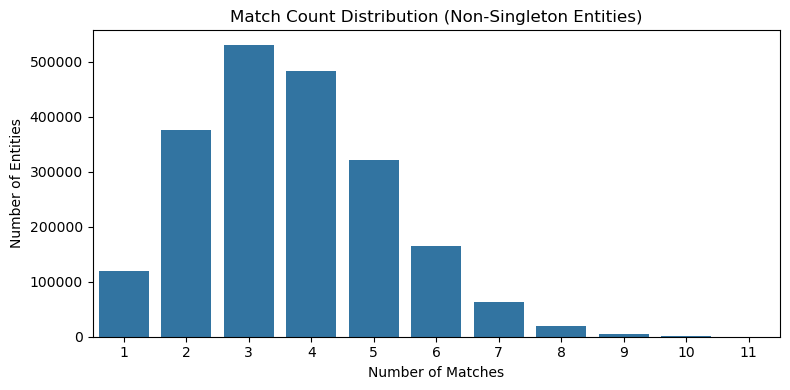

In [12]:
match_counts = non_singleton["num_matches"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

sns.barplot(
    x=match_counts.index,
    y=match_counts.values
)

plt.xlabel("Number of Matches")
plt.ylabel("Number of Entities")
plt.title("Match Count Distribution (Non-Singleton Entities)")

plt.tight_layout()
plt.show()

Checking for Non-Latin Script in Business Names

Why we are doing this:

* During manual inspection of Source2 and Source3 samples, we noticed some business names written in Devanagari (Hindi) and Tamil script, not just English. This is different from what the problem statement called "transliteration variants" — these appear to be entirely different scripts, not just spelling variants. Before deciding how to handle this, we need to confirm: does this happen in all three sources, or only some? This tells us whether we need script conversion in one direction or multiple directions.

Result:

Source1: 0 / 2,206,821 non-Latin-script names (0%)

Source2: 764,608 / 5,034,616 non-Latin-script names (15.19%)

Source3: 606,737 / 5,285,603 non-Latin-script names (11.48%)

-   Interpretation:

Source1 is entirely in Roman/English script, while Source2 and Source3 both contain a meaningful fraction of non-Latin-script names. This means script conversion only needs to happen in one direction — Source2/Source3 → Roman script — to make comparison against Source1 possible.

In [ ]:

def has_non_latin(text):
    if pd.isna(text):
        return False
    # if any character is out of ASCII range (basic Latin), assume it to non-Latin script
    return bool(re.search(r'[^\x00-\x7F]', str(text)))

s1_non_latin = df_source1["business_name"].apply(has_non_latin).sum()
s2_non_latin = df_source2["business_name"].apply(has_non_latin).sum()
s3_non_latin = df_source3["business_name"].apply(has_non_latin).sum()

print(f"Source1 non-Latin-script names: {s1_non_latin} / {len(df_source1)}")
print(f"Source2 non-Latin-script names: {s2_non_latin} / {len(df_source2)}")
print(f"Source3 non-Latin-script names: {s3_non_latin} / {len(df_source3)}")

Source1 non-Latin-script names: 0 / 2206821
Source2 non-Latin-script names: 764608 / 5034616
Source3 non-Latin-script names: 606737 / 5285603


- Is Non-Latin Script Limited to India Records?

- Why we are doing this:

Non-Latin script is most likely a feature of India-based businesses. If true, we would only need to apply script conversion to India-labeled records, saving compute on the much larger US-labeled portion.


- This was unexpected: we expected the US percentage to be close to 0%, but it is 6.70-6.80% — a meaningful, non-trivial number. Since US business names have no reason to contain Devanagari or Tamil script, this strongly suggests our detection method is flawed rather than the data being unusual.

- Likely cause: our check ([^\x00-\x7F]) flags any character outside plain ASCII — which also includes accented Latin letters (é, ñ, ü, etc.) common in US business/surname spellings (e.g. we had already seen "Béque" in Source3 samples). These are still Roman script and don't need transliteration; our check was too broad.

- Next step: replace the ASCII-based check with one that specifically detects Devanagari and Tamil Unicode ranges, then re-run this same country breakdown to see if the US percentage drops close to 0%.

In [14]:
def non_latin_summary(df, source_name):
    df["_non_latin"] = df["business_name"].apply(has_non_latin)
    summary = df.groupby("country")["_non_latin"].agg(["sum", "count"])
    summary["pct"] = (summary["sum"] / summary["count"] * 100).round(2)
    summary.columns = ["non_latin_count", "total_count", "non_latin_pct"]
    summary.insert(0, "source", source_name)
    df.drop(columns="_non_latin", inplace=True)  # cleanup temp column
    return summary.reset_index()

source2_summary = non_latin_summary(df_source2, "Source2")
source3_summary = non_latin_summary(df_source3, "Source3")

non_latin_by_country = pd.concat([source2_summary, source3_summary], ignore_index=True)
non_latin_by_country

,country,source,non_latin_count,total_count,non_latin_pct
0,India,Source2,562437,2017799,27.87
1,US,Source2,202171,3016817,6.70
2,India,Source3,391172,2115547,18.49
3,US,Source3,215565,3170056,6.80


-   Why we did this: The previous ASCII-based check was flagging accented Latin characters (like "é" in "Béque") as non-Latin, giving a false 6.70-6.80% in US records. We switched to checking specifically for Devanagari (U+0900–U+097F) and Tamil (U+0B80–U+0BFF) Unicode ranges instead.

- Interpretation: The fix confirms the hypothesis — Devanagari/Tamil script appears only in India-labeled records, and US percentage is exactly 0% now. This means the earlier ASCII check was indeed catching false positives (accented Latin letters), not real Indic script.

- Decision for pipeline design: Transliteration only needs to run on India-labeled Source2/Source3 records (~15% and ~8.4% of India rows respectively actually need it — most India rows are already in Roman script). This is a conditional step, not a blanket one, which saves compute and avoids risk of corrupting already-clean Roman-script names.

In [15]:
def has_indic_script(text):
    if pd.isna(text):
        return False
    text = str(text)
    for ch in text:
        code = ord(ch)
        if (0x0900 <= code <= 0x097F) or (0x0B80 <= code <= 0x0BFF):
            return True
    return False

In [16]:
def indic_script_summary(df, source_name):
    df["_indic"] = df["business_name"].apply(has_indic_script)
    summary = df.groupby("country")["_indic"].agg(["sum", "count"])
    summary["pct"] = (summary["sum"] / summary["count"] * 100).round(2)
    summary.columns = ["indic_count", "total_count", "indic_pct"]
    summary.insert(0, "source", source_name)
    df.drop(columns="_indic", inplace=True)  # cleanup temp column
    return summary.reset_index()

source2_indic = indic_script_summary(df_source2, "Source2")
source3_indic = indic_script_summary(df_source3, "Source3")

indic_by_country = pd.concat([source2_indic, source3_indic], ignore_index=True)
indic_by_country

,country,source,indic_count,total_count,indic_pct
0,India,Source2,303205,2017799,15.03
1,US,Source2,0,3016817,0.00
2,India,Source3,177793,2115547,8.40
3,US,Source3,0,3170056,0.00


Missing Address Check

- Why we are doing this: 
    - We had already spotted one example of a missing address (S3-859268022, address = NaN) during manual inspection. We need to know how common this is across all three sources, because it directly affects how the matching model and blocking key should be designed.
    
- Interpretation: 
    - Source1 has no missing addresses, consistent with it being the "clean" reference source. Source2 and Source3 each have ~3.3% missing addresses (~169K-176K records). This is not negligible, and requires two design accommodations:

- Blocking: records with missing address need a name-only blocking path, since any address-based blocking key won't exist for them.

- Matching model: address-similarity features must be treated as neutral/missing (not as "no match") when either side of a candidate pair has no address, to avoid false negatives.

In [24]:
def missing_address_summary(df, source_name):
    missing = df["business_address"].isna().sum()
    total = len(df)
    return pd.DataFrame([{
        "source": source_name,
        "missing_address_count": missing,
        "total_count": total,
        "missing_pct": round(missing / total * 100, 2)
    }])

address_summary = pd.concat([
    missing_address_summary(df_source1, "Source1"),
    missing_address_summary(df_source2, "Source2"),
    missing_address_summary(df_source3, "Source3"),
], ignore_index=True)

address_summary

,source,missing_address_count,total_count,missing_pct
0,Source1,0,2206821,0.00
1,Source2,168967,5034616,3.36
2,Source3,175916,5285603,3.33


In [18]:
def garbage_prefix_summary(df, col, source_name):
    # leading characters which are not letters/digits (like --, #, ##)
    has_garbage = df[col].astype(str).str.match(r'^[^a-zA-Z0-9]')
    count = has_garbage.sum()
    total = len(df)
    return pd.DataFrame([{
        "source": source_name,
        "column": col,
        "garbage_prefix_count": count,
        "total_count": total,
        "garbage_pct": round(count / total * 100, 2)
    }])

garbage_summary = pd.concat([
    garbage_prefix_summary(df_source1, "business_name", "Source1"),
    garbage_prefix_summary(df_source2, "business_name", "Source2"),
    garbage_prefix_summary(df_source3, "business_name", "Source3"),
], ignore_index=True)

garbage_summary

,source,column,garbage_prefix_count,total_count,garbage_pct
0,Source1,business_name,3181,2206821,0.14
1,Source2,business_name,577243,5034616,11.47
2,Source3,business_name,378668,5285603,7.16


Leading Garbage Character Analysis

- Why we did this: 
    - After finding that ~11% of Source2 and ~7% of Source3 business names have a non-alphanumeric leading character, we needed to know exactly which characters these are, to design a precise cleaning rule.
- First attempt problem:
    - Our first check flagged Devanagari letters (स, ग, ब, श) as "garbage" — these are actually valid first letters of legitimate Hindi business names, not noise. Root cause: the check only treated ASCII alphanumerics as valid.
- Second attempt problem: 
    - After excluding Devanagari/Tamil, two more scripts appeared as false positives — Telugu (స) and Kannada (ಸ). This showed our initial two-script assumption (based on manual sampling) was incomplete — the data contains a broader range of Indian scripts than what we had directly observed.

- Fix: Excluded all 9 major Indian scripts (Devanagari, Bengali, Gurmukhi, Gujarati, Oriya, Tamil, Telugu, Kannada, Malayalam) by Unicode range, instead of only the ones spotted by eye.

- Interpretation: 
    - The list is now dominated by genuine punctuation/formatting noise (#, @, -, ., (, [, *, >, &). One residual false positive remains — Í (an accented Latin letter, like in "Béque" earlier) — but at ~0.03% of records, it's negligible and not worth adding complexity for at this stage.

- Decision: 
    - The cleaning function should strip leading occurrences of # @ > * - . ( ) [ ' / & (and similar symbols) from business names, while leaving all Indic-script and accented-Latin characters untouched.

In [ ]:

def get_leading_char(text):
    text = str(text)
    match = re.match(r'^([^a-zA-Z0-9])', text)
    return match.group(1) if match else None

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    leading_chars = df["business_name"].apply(get_leading_char).dropna()
    print(f"\n{name} — top leading garbage characters:")
    print(leading_chars.value_counts().head(10))


Source1 — top leading garbage characters:
business_name
#    1401
(    1149
@     506
<     104
.       8
)       5
-       4
'       3
/       1
Name: count, dtype: int64

Source2 — top leading garbage characters:
business_name
स    39755
ग    23568
ब    21287
श    18536
#    17595
@    16068
>    14909
*    14747
-    14716
.    14578
Name: count, dtype: int64

Source3 — top leading garbage characters:
business_name
स    22308
#    18505
@    16498
*    15480
.    15343
>    15257
-    15184
ग    13304
ब    11929
श    10243
Name: count, dtype: int64


In [20]:
def get_leading_garbage_char(text):
    text = str(text)
    if not text:
        return None
    first_char = text[0]
    code = ord(first_char)
    # Valid ranges: English letters/digits, or Devanagari, or Tamil
    is_alnum = first_char.isalnum() and ord(first_char) < 128  # ASCII alnum
    is_devanagari = 0x0900 <= code <= 0x097F
    is_tamil = 0x0B80 <= code <= 0x0BFF
    if is_alnum or is_devanagari or is_tamil:
        return None  # valid start, not garbage 
    return first_char

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    leading_chars = df["business_name"].apply(get_leading_garbage_char).dropna()
    print(f"\n{name} — top leading garbage characters (Indic excluded):")
    print(leading_chars.value_counts().head(10))


Source1 — top leading garbage characters (Indic excluded):
business_name
#    1401
(    1149
@     506
<     104
.       8
)       5
-       4
'       3
/       1
Name: count, dtype: int64

Source2 — top leading garbage characters (Indic excluded):
business_name
#    17595
@    16068
>    14909
*    14747
-    14716
.    14578
(     8678
[     6195
స     5866
ಸ     5540
Name: count, dtype: int64

Source3 — top leading garbage characters (Indic excluded):
business_name
#    18505
@    16498
*    15480
.    15343
>    15257
-    15184
(     9502
[     6969
స     3202
ಸ     3139
Name: count, dtype: int64


In [21]:
INDIC_RANGES = [
    (0x0900, 0x097F),  # Devanagari (Hindi, Marathi, etc.)
    (0x0980, 0x09FF),  # Bengali
    (0x0A00, 0x0A7F),  # Gurmukhi (Punjabi)
    (0x0A80, 0x0AFF),  # Gujarati
    (0x0B00, 0x0B7F),  # Oriya
    (0x0B80, 0x0BFF),  # Tamil
    (0x0C00, 0x0C7F),  # Telugu
    (0x0C80, 0x0CFF),  # Kannada
    (0x0D00, 0x0D7F),  # Malayalam
]

def is_indic_char(ch):
    code = ord(ch)
    return any(start <= code <= end for start, end in INDIC_RANGES)

def get_leading_garbage_char(text):
    text = str(text)
    if not text:
        return None
    first_char = text[0]
    is_ascii_alnum = first_char.isalnum() and ord(first_char) < 128
    if is_ascii_alnum or is_indic_char(first_char):
        return None
    return first_char

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    leading_chars = df["business_name"].apply(get_leading_garbage_char).dropna()
    print(f"\n{name} — top leading garbage characters (all Indic scripts excluded):")
    print(leading_chars.value_counts().head(10))


Source1 — top leading garbage characters (all Indic scripts excluded):
business_name
#    1401
(    1149
@     506
<     104
.       8
)       5
-       4
'       3
/       1
Name: count, dtype: int64

Source2 — top leading garbage characters (all Indic scripts excluded):
business_name
#    17595
@    16068
>    14909
*    14747
-    14716
.    14578
(     8678
[     6195
Í     1379
&     1160
Name: count, dtype: int64

Source3 — top leading garbage characters (all Indic scripts excluded):
business_name
#    18505
@    16498
*    15480
.    15343
>    15257
-    15184
(     9502
[     6969
Í     1278
&     1130
Name: count, dtype: int64


- Why we did this: 
    - To build a suffix-normalization dictionary (so "Pvt Ltd" and "Private Limited" map to the same canonical form), we needed to see the actual most common trailing words in business names across all three sources — rather than guessing the list from memory.
- First attempt problem: 
    - A single-letter word "c" appeared 45K-81K times across sources — this wasn't a real suffix, it was a parsing artifact. Dotted abbreviations like "L.L.C." or "P.C." were being split on periods, turning them into isolated single letters (l, l, c) instead of one token.
- Fix: 
    - Added a step to collapse dotted abbreviation patterns (e.g. L.L.C. → LLC) before extracting the last word.

**Result after fix (top last-words):**

Source	Top suffix-like words

Source1 :-	limited, llc, inc, ltd, pc, llp, corp, group, co, associates, pllc, partners, clinic, lp, corporation, company, trust, holdings

Source2	:- llc, limited, ltd, inc, com, center, private, corp, co, services, partners, group, llp, holdings, corporation, service, lp, pc, pvt, company

Source3 :-	llc, limited, ltd, inc, com, center, private, corp, co, services, partners, group, llp, holdings, service, corporation, pc, lp, pvt, associates


**Other Observation**
- "com" appears very frequently in Source2/3 (200K+) but not Source1 — these are businesses whose name is literally a website domain (e.g. heassociates.com). This is a separate naming pattern, not a legal suffix — it should not be included in the suffix-normalization mapping, since collapsing "X.com" to "X" would be incorrect.

- "private"/"pvt" appear as standalone last-words in Source2/3 but not prominently in Source1 — consistent with Source1 being more standardized (likely always spelling out "Private Limited" in full), while S2/S3 sometimes truncate it (e.g. just "... Pvt" with "Ltd" dropped, or "... Private" alone).

- Decision: 
    - Build the suffix-normalization dictionary from this confirmed list (limited↔ltd, corporation↔corp, company↔co, private↔pvt, llc, llp, pllc, lp, pc, inc, group, associates, partners, holdings, trust), and explicitly exclude "com" from it since it's a domain-name artifact, not a legal suffix.

In [ ]:
def get_last_word(text):
    if pd.isna(text):
        return None
    text = str(text)
    # Split words after removing punctueation
    words = re.findall(r"[A-Za-z]+", text)
    if not words:
        return None
    return words[-1].lower()

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    last_words = df["business_name"].apply(get_last_word).dropna()
    print(f"\n{name} — top last-words in business_name:")
    print(last_words.value_counts().head(20))


Source1 — top last-words in business_name:
business_name
limited        521915
llc            355736
inc            238306
ltd            148595
c               45559
llp             39725
corp            33761
group           32678
pc              25827
co              25191
center          22269
associates      22165
pllc            20531
partners        19351
clinic          18107
care            16845
lp              16477
corporation     13540
company         12316
trust            9924
Name: count, dtype: int64

Source2 — top last-words in business_name:
business_name
limited        425212
llc            413625
ltd            350528
inc            321537
com            200474
center         146872
private        119991
corp           118254
co             111818
services        98931
partners        92074
c               81714
group           80893
holdings        60907
corporation     54774
llp             50121
service         45884
lp              42957
pvt             37332


In [23]:
def normalize_dotted_abbreviations(text):
    # "L.L.C." -> "LLC", "P.C." -> "PC" (Remove the periods and join the consecutive single letters)
    text = re.sub(r'\b(?:[A-Za-z]\.){2,}', lambda m: m.group(0).replace('.', ''), text)
    return text

def get_last_word_v2(text):
    if pd.isna(text):
        return None
    text = normalize_dotted_abbreviations(str(text))
    words = re.findall(r"[A-Za-z]+", text)
    if not words:
        return None
    return words[-1].lower()

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    last_words = df["business_name"].apply(get_last_word_v2).dropna()
    print(f"\n{name} — top last-words (v2, dotted abbreviations fixed):")
    print(last_words.value_counts().head(20))


Source1 — top last-words (v2, dotted abbreviations fixed):
business_name
limited        521915
llc            377579
inc            238306
ltd            148595
pc              47867
llp             39725
corp            33761
group           32678
co              25191
center          22269
associates      22165
pllc            20531
partners        19351
clinic          18107
care            16845
lp              16477
corporation     13540
company         12316
trust            9924
holdings         8309
Name: count, dtype: int64

Source2 — top last-words (v2, dotted abbreviations fixed):
business_name
llc            469020
limited        425212
ltd            350528
inc            321534
com            200474
center         146872
private        119991
corp           118250
co             111818
services        98931
partners        92074
group           80893
llp             61267
holdings        60907
corporation     54774
service         45884
lp              42956
pc          

# Feature Engineering

#### Business Name Normalization

- Why we built this: 
    - Based on everything discovered in EDA — dotted abbreviations (L.L.C. → LLC), leading garbage characters (#, @, --), legal suffix variations (limited/ltd, corporation/corp), and duplicate trailing words (LLC LLC) — we combined all fixes into a single normalize_business_name() function, applied in this order: collapse dotted abbreviations → strip leading garbage → lowercase → remove consecutive duplicate words → normalize suffix.

- Tested on samples, including edge cases (Indic-script names left untouched, middle initials like "E." preserved, duplicate suffix collapsed). Confirmed working correctly:

'Ollszewski Holding Company LLC LLC' → 'ollszewski holding company llc'

In [33]:
import re

# Suffix mapping — humne jo EDA me discover kiya tha usi se banaya
SUFFIX_MAP = {
    "limited": "ltd",
    "corporation": "corp",
    "company": "co",
    "private": "pvt",
    # ye already short-form hain, apne aap map ho jaayenge (identity mapping ki zarurat nahi)
}

def collapse_dotted_abbreviations(text):
    return re.sub(r'\b(?:[A-Za-z]\.){2,}', lambda m: m.group(0).replace('.', ''), text)

def strip_leading_garbage(text):
    while text and not (text[0].isalnum() or is_indic_char(text[0])):
        text = text[1:]
    return text

def normalize_suffix(text):
    words = text.split()
    if not words:
        return text
    last = words[-1].lower()
    if last in SUFFIX_MAP:
        words[-1] = SUFFIX_MAP[last]
    return " ".join(words)

def remove_consecutive_duplicate_words(text):
    words = text.split()
    if not words:
        return text
    deduped = [words[0]]
    for w in words[1:]:
        if w != deduped[-1]:
            deduped.append(w)
    return " ".join(deduped)

def normalize_business_name(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = collapse_dotted_abbreviations(text)
    text = strip_leading_garbage(text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)  # multiple spaces -> single space
    text = remove_consecutive_duplicate_words(text)   
    text = normalize_suffix(text)
    return text

In [ ]:
sample_names = [
    "-- Holloway Peak Inc Seafood",
    "#centraleducation",
    "Ectolumdrex dba X+ Madison Inc",
    "Ollszewski Holding Company LLC LLC",
    "Aggie E. Nagle, L.C.S.W.",
    "राम मार्केटिंग प्राइवेट लिमिटेड",
    "##8 Willow Oak Lane",  
]

for name in sample_names:
    print(f"{name!r}  ->  {normalize_business_name(name)!r}")

'-- Holloway Peak Inc Seafood'  ->  'holloway peak inc seafood'
'#centraleducation'  ->  'centraleducation'
'Ectolumdrex dba X+ Madison Inc'  ->  'ectolumdrex dba x+ madison inc'
'Ollszewski Holding Company LLC LLC'  ->  'ollszewski holding company llc llc'
'Aggie E. Nagle, L.C.S.W.'  ->  'aggie e. nagle, lcsw'
'राम मार्केटिंग प्राइवेट लिमिटेड'  ->  'राम मार्केटिंग प्राइवेट लिमिटेड'
'##8 Willow Oak Lane'  ->  '8 willow oak lane'


In [34]:
print(normalize_business_name("Ollszewski Holding Company LLC LLC"))

ollszewski holding company llc


In [31]:
def has_duplicate_trailing_suffix(text):
    words = str(text).lower().split()
    if len(words) < 2:
        return False
    return words[-1] == words[-2]

for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    dup_count = df["business_name"].apply(has_duplicate_trailing_suffix).sum()
    print(f"{name}: {dup_count} / {len(df)} names with duplicate trailing word ({dup_count/len(df)*100:.3f}%)")

Source1: 1262 / 2206821 names with duplicate trailing word (0.057%)
Source2: 37920 / 5034616 names with duplicate trailing word (0.753%)
Source3: 39814 / 5285603 names with duplicate trailing word (0.753%)


In [35]:
df_source1["business_name_norm"] = df_source1["business_name"].apply(normalize_business_name)
df_source2["business_name_norm"] = df_source2["business_name"].apply(normalize_business_name)
df_source3["business_name_norm"] = df_source3["business_name"].apply(normalize_business_name)


In [36]:
# quick visual check
df_source2[["business_name", "business_name_norm"]].sample(10, random_state=42)

,business_name,business_name_norm
2641297,Harbor Center,harbor center
1856454,STEWARD ACE PREMIER,steward ace premier
371269,Klapper and Lott,klapper and lott
793182,EAR NOSE & THROAT CARE,ear nose & throat care
4159519,Shield Inrfabuild Private Limited,shield inrfabuild private ltd
2290871,#holtline,holtline
2479261,Cancer [Services],cancer [services]
606462,Smt Hermes Private Limited Center,smt hermes private limited center
3805434,AMARDEEP PTER PRIVATE LIMITED,amardeep pter private ltd
2960649,Impex-+-Brothers,impex-+-brothers


#### Address Notmalization
- Why we did this: 
    - Address needed similar cleaning to business_name (garbage characters, missing values), but the patterns are different — direct reuse of the name-cleaning logic would have been wrong.
- Key finding 1 — 
    - '#' means something different in addresses: Unlike business_name (where # was pure noise), address samples showed # is used as a house/door-number prefix (e.g. #17/1), especially in Indian addresses. Stripping it would have deleted real content. We also found a duplication pattern (##, ###) — same kind of noise as the "LLC LLC" case in business_name, but at the character level instead of word level. Fix: collapse multiple # into one, but preserve it (unlike business_name where # is fully stripped).
- Key finding 2 — 
    - <NULL> placeholder text: Found addresses containing a literal <NULL> token standing in for a missing field (e.g. "#2, <NULL>, MUMBAI, Maharashtra"), not caught by our earlier isna()-based missing-address check since the string itself isn't null to pandas. Quantified: 43,799 occurrences in Source2 and 43,572 in Source3 (0 in Source1), always as a partial field, never as the entire address. Fix: strip the <NULL> token wherever it appears, then clean up resulting orphaned commas.

- Final function combines: 
    - remove <NULL> tokens → strip leading garbage (preserving #) → lowercase → clean whitespace. Tested on mixed cases (both issues combined, plain missing values) — all passed as expected.

In [37]:
# address me bhi leading garbage check karte hain (wahi function reuse karke)
for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    leading_chars = df["business_address"].dropna().apply(get_leading_garbage_char).dropna()
    print(f"\n{name} — top leading garbage chars in address:")
    print(leading_chars.value_counts().head(10))


Source1 — top leading garbage chars in address:
business_address
#    7735
'     326
(     108
.      33
`      22
:      17
/       6
?       6
)       6
Â       6
Name: count, dtype: int64

Source2 — top leading garbage chars in address:
business_address
#    257722
<      2365
'       520
(       175
-        71
.        70
&        57
/        37
`        35
:        30
Name: count, dtype: int64

Source3 — top leading garbage chars in address:
business_address
#    262154
<      2105
'       587
(       305
&       204
-       129
.        62
`        46
/        40
:        36
Name: count, dtype: int64


In [38]:
import random

for name, df in [("Source2", df_source2), ("Source3", df_source3)]:
    hash_addresses = df["business_address"].dropna()
    hash_addresses = hash_addresses[hash_addresses.str.startswith("#")]
    sample = hash_addresses.sample(min(15, len(hash_addresses)), random_state=42)
    print(f"\n{name} — sample addresses starting with '#':")
    for addr in sample:
        print(" ", addr)


Source2 — sample addresses starting with '#':
  ##1795 MT SPRINGS RD, CABOT, AR
  ##4013 OGDEN AVENUE, CHICAGO, IL
  #146 HIDEAWAY LANE, MOORESVILLE, NC
  ##8220 PROLE RD, STAFFORD, NY
  #3927 ORIOLE AVENUE, CHICAGO, IL
  ###6 , BHOMAJI SHIVAJI WADI, OPP. VAKOLA CHURCH, NEHRU ROAD, SANTACRU, Z EAST, महाराष्ट्र
  ###26 / 1, JAGAT RAY CHOWDHURY ROAD SAKHER BAZAR, BARISHA, KOLKATA, KOLKATA, West Bengal
  #2, <NULL>, MUMBAI, Maharashtra
  ##427 1580, HYRUM, UT
  ##468 1257, ABHAY PALACE LUNAHAR, SALIPUR, CUTTACK, Orissa
  ##3329 PENROSE COURT, TOLEDO CDP, OH
  #13236 Fifth Street, CHINO, CA
  ###207 , 2ND FLOOR, CLASSIC APARTMENTS, S P OFFICE ROAD, KOLHAPUR CIRCLE, BELGAUM, Karnataka
  #24 , 6TH BLOCK, 1ST MAIN BEL LAYOUT, VIDYARANYAPURA, Karnataka
  #724 A-84-85 3RD FLOOR VIVEK, VIHAR PHASE II NEAR PARK, SHAHDARA, Delhi

Source3 — sample addresses starting with '#':
  ##3554 News Rd, James City County, Virginia
  #3/586 Vikas Nagar, Lucknow -1133, Lucknow, UP
  #W6700 20th Drive, Town Of

In [45]:
def strip_leading_garbage_address(text):
    text = re.sub(r'^#+', '#', text)          # multiple # ko ek # bana do (agar # hai to)
    while text and not (text[0].isalnum() or text[0] == '#' or is_indic_char(text[0])):
        text = text[1:]
    return text

def remove_null_tokens(text):
    # <NULL> (kisi bhi case variation me) ko hata do
    text = re.sub(r'<\s*null\s*>', '', text, flags=re.IGNORECASE)
    # isse jo extra ", ," ya trailing/leading comma-space bache, unko clean karo
    text = re.sub(r',\s*,', ',', text)          # double comma -> single
    text = re.sub(r'^\s*,\s*', '', text)         # leading comma
    text = re.sub(r',\s*$', '', text)            # trailing comma
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_address(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = remove_null_tokens(text)
    text = strip_leading_garbage_address(text)
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

In [40]:
test_addresses = [
    "##1795 MT SPRINGS RD, CABOT, AR",
    "###6 , BHOMAJI SHIVAJI WADI, OPP. VAKOLA CHURCH",
    "#2, <NULL>, MUMBAI, Maharashtra",
    "<NULL>",
]

for addr in test_addresses:
    print(f"{addr!r}  ->  {strip_leading_garbage_address(addr)!r}")

'##1795 MT SPRINGS RD, CABOT, AR'  ->  '#1795 MT SPRINGS RD, CABOT, AR'
'###6 , BHOMAJI SHIVAJI WADI, OPP. VAKOLA CHURCH'  ->  '#6 , BHOMAJI SHIVAJI WADI, OPP. VAKOLA CHURCH'
'#2, <NULL>, MUMBAI, Maharashtra'  ->  '#2, <NULL>, MUMBAI, Maharashtra'
'<NULL>'  ->  'NULL>'


In [41]:
for name, df in [("Source1", df_source1), ("Source2", df_source2), ("Source3", df_source3)]:
    addr = df["business_address"].dropna().astype(str)
    contains_null = addr.str.contains("<NULL>", case=False, regex=False).sum()
    exact_null = (addr.str.strip() == "<NULL>").sum()
    print(f"{name}: contains '<NULL>' anywhere = {contains_null}, "
          f"address is ONLY '<NULL>' = {exact_null}, out of {len(addr)}")

Source1: contains '<NULL>' anywhere = 0, address is ONLY '<NULL>' = 0, out of 2206821
Source2: contains '<NULL>' anywhere = 43799, address is ONLY '<NULL>' = 0, out of 4865649
Source3: contains '<NULL>' anywhere = 43572, address is ONLY '<NULL>' = 0, out of 5109687


In [43]:
test_cases = [
    "#2, <NULL>, MUMBAI, Maharashtra",
    "<NULL>, some street, City",
    "123 Main St, <NULL>",
]

for t in test_cases:
    print(f"{t!r}  ->  {remove_null_tokens(t)!r}")

'#2, <NULL>, MUMBAI, Maharashtra'  ->  '#2, MUMBAI, Maharashtra'
'<NULL>, some street, City'  ->  'some street, City'
'123 Main St, <NULL>'  ->  '123 Main St'


In [46]:
test_addresses = [
    "#2, <NULL>, MUMBAI, Maharashtra",
    "##1795 MT SPRINGS RD, CABOT, AR",
    "<NULL>",
    "105 ELM ST, MORGANTON, NC",
    None,
]

for addr in test_addresses:
    print(f"{addr!r}  ->  {normalize_address(addr)!r}")

'#2, <NULL>, MUMBAI, Maharashtra'  ->  '#2, mumbai, maharashtra'
'##1795 MT SPRINGS RD, CABOT, AR'  ->  '#1795 mt springs rd, cabot, ar'
'<NULL>'  ->  ''
'105 ELM ST, MORGANTON, NC'  ->  '105 elm st, morganton, nc'
None  ->  ''


In [47]:
df_source1["business_address_norm"] = df_source1["business_address"].apply(normalize_address)
df_source2["business_address_norm"] = df_source2["business_address"].apply(normalize_address)
df_source3["business_address_norm"] = df_source3["business_address"].apply(normalize_address)

In [51]:
df_source2[["business_address", "business_address_norm"]].sample(10, random_state=42)

,business_address,business_address_norm
2641297,"6309 EVANGELINE TRAIL, AUSTIN, TX","6309 evangeline trail, austin, tx"
1856454,"1029 MAPLE HILL RD, LEBANON, TN","1029 maple hill rd, lebanon, tn"
371269,"368 VINE STREET, TOOELE, UT","368 vine street, tooele, ut"
793182,"YORK RD, LUTHERVILLE, MD","york rd, lutherville, md"
4159519,"206 FLAT NO. LG 1 KH NO. 514, 516 SHYAM BHAWAN...","206 flat no. lg 1 kh no. 514, 516 shyam bhawan..."
2290871,"HOUSTON, 6119 DARLINGHURST DRIVE, TX","houston, 6119 darlinghurst drive, tx"
2479261,NaN,
606462,"Delhi, HOUSE NO 138, 2ND FLOOR, BLK C, PKT 2 D...","delhi, house no 138, 2nd floor, blk c, pkt 2 d..."
3805434,"332NEAR TELCO SERVICE STATION RANGPURI, NEW DE...","332near telco service station rangpuri, new de..."
2960649,"FLAT B 1801, PL-15&17, SECTOR 7, PATEL HERITAG...","flat b 1801, pl-15&17, sector 7, patel heritag..."


#### Blocking

In [52]:
def get_first_token(name):
    if not name:
        return ""
    return name.split()[0] if name.split() else ""

df_source1["block_key"] = df_source1["country"] + "|" + df_source1["business_name_norm"].apply(get_first_token)
df_source2["block_key"] = df_source2["country"] + "|" + df_source2["business_name_norm"].apply(get_first_token)
df_source3["block_key"] = df_source3["country"] + "|" + df_source3["business_name_norm"].apply(get_first_token)

# block size distribution dekhte hain — kitne records ek block me aa rahe hain
block_sizes_s2 = df_source2.groupby("block_key").size()
print("Source2 block size stats:")
print(block_sizes_s2.describe())
print(f"\nTotal unique blocks: {len(block_sizes_s2)}")
print(f"Blocks with only 1 record: {(block_sizes_s2 == 1).sum()}")

Source2 block size stats:
count    486013.000000
mean         10.359015
std         200.540399
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max       42966.000000
dtype: float64

Total unique blocks: 486013
Blocks with only 1 record: 331494


In [53]:
top_blocks = block_sizes_s2.sort_values(ascending=False).head(15)
print("Top 15 largest blocks in Source2:")
print(top_blocks)

Top 15 largest blocks in Source2:
block_key
US|llc           42966
US|the           39762
India|private    38646
US|pediatric     28613
India|shri       25699
India|m/s        25661
India|sri        25650
India|dr         25648
India|smt        25473
India|mr         25444
US|inc           19781
India|limited    14387
India|new        13062
US|family        12410
US|a             10800
dtype: int64


In [54]:
PREFIX_NOISE_WORDS = {"llc", "inc", "ltd", "limited", "corp", "corporation", "private", "pvt",
                       "the", "a", "an", "m/s", "shri", "sri", "smt", "mr", "dr", "mrs", "ms"}

def get_first_meaningful_token(name):
    if not name:
        return ""
    tokens = name.split()
    for tok in tokens:
        clean_tok = tok.strip(".,/")
        if clean_tok not in PREFIX_NOISE_WORDS:
            return clean_tok
    return tokens[0] if tokens else ""  # agar sab prefix-noise hi the, to pehla hi le lo

In [55]:
df_source2["block_key_v2"] = df_source2["country"] + "|" + df_source2["business_name_norm"].apply(get_first_meaningful_token)

block_sizes_s2_v2 = df_source2.groupby("block_key_v2").size()
print("Source2 block size stats (v2):")
print(block_sizes_s2_v2.describe())
print(f"\nTop 10 largest blocks (v2):")
print(block_sizes_s2_v2.sort_values(ascending=False).head(10))

Source2 block size stats (v2):
count    482348.000000
mean         10.437725
std         152.240849
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max       30008.000000
dtype: float64

Top 10 largest blocks (v2):
block_key_v2
US|pediatric    30008
India|new       14525
US|family       12990
US|ear          10395
US|eye          10310
US|foot         10243
US|physical     10200
US|blue         10198
US|primary      10105
India|mumbai    10083
dtype: int64


In [56]:
def get_last_address_token(addr_norm):
    if not addr_norm:
        return ""
    # comma se split karke last non-empty part lo, phir uska pehla word lo (state code jaisa)
    parts = [p.strip() for p in addr_norm.split(",") if p.strip()]
    if not parts:
        return ""
    return parts[-1].split()[0] if parts[-1].split() else ""

df_source2["block_key_v3"] = (
    df_source2["country"] + "|" +
    df_source2["business_name_norm"].apply(get_first_meaningful_token) + "|" +
    df_source2["business_address_norm"].apply(get_last_address_token)
)

block_sizes_s2_v3 = df_source2.groupby("block_key_v3").size()
print("Source2 block size stats (v3):")
print(block_sizes_s2_v3.describe())
print(f"\nTop 10 largest blocks (v3):")
print(block_sizes_s2_v3.sort_values(ascending=False).head(10))

Source2 block size stats (v3):
count    1.640387e+06
mean     3.069164e+00
std      2.009511e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.928000e+03
dtype: float64

Top 10 largest blocks (v3):
block_key_v3
India|new|delhi              6928
India|mumbai|maharashtra     6471
India|bangalore|karnataka    4863
India|delhi|delhi            4248
India|kolkata|west           3763
India|pune|maharashtra       3561
US|pediatric|tx              2590
India|chennai|tamil          2348
India|new|दिल्ली             2326
India|mumbai|महाराष्ट्र      2138
dtype: int64


In [57]:
for name, df in [("Source2", df_source2), ("Source3", df_source3)]:
    addr = df["business_address_norm"].dropna()
    has_indic = addr.apply(lambda t: any(is_indic_char(ch) for ch in t))
    print(f"{name} — addresses with Indic script: {has_indic.sum()} / {len(addr)} ({has_indic.sum()/len(addr)*100:.2f}%)")

Source2 — addresses with Indic script: 477521 / 5034616 (9.48%)
Source3 — addresses with Indic script: 475778 / 5285603 (9.00%)


In [59]:
!pip install indic-transliteration

  Using cached indic_transliteration-2.3.82-py3-none-any.whl.metadata (1.8 kB)
  Using cached backports.functools_lru_cache-2.0.0-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached roman-5.2-py3-none-any.whl.metadata (4.3 kB)
Using cached indic_transliteration-2.3.82-py3-none-any.whl (162 kB)
Using cached backports.functools_lru_cache-2.0.0-py2.py3-none-any.whl (6.7 kB)
Using cached roman-5.2-py3-none-any.whl (6.0 kB)

   -------------------------- ------------- 2/3 [indic-transliteration]
   ---------------------------------------- 3/3 [indic-transliteration]



In [60]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

test_strings = [
    "दिल्ली",
    "महाराष्ट्र",
    "राम मार्केटिंग प्राइवेट लिमिटेड",
]

for s in test_strings:
    result = transliterate(s, sanscript.DEVANAGARI, sanscript.ITRANS)
    print(f"{s}  ->  {result}")

दिल्ली  ->  dillI
महाराष्ट्र  ->  mahArAShTra
राम मार्केटिंग प्राइवेट लिमिटेड  ->  rAma mArkeTiMga prAiveTa limiTeDa


In [61]:
def simple_edit_distance_ratio(a, b):
    import difflib
    return difflib.SequenceMatcher(None, a.lower(), b.lower()).ratio()

pairs = [
    ("dillI", "delhi"),
    ("mahArAShTra", "maharashtra"),
]

for translit, actual in pairs:
    ratio = simple_edit_distance_ratio(translit, actual)
    print(f"{translit!r} vs {actual!r}  ->  similarity = {ratio:.3f}")

'dillI' vs 'delhi'  ->  similarity = 0.400
'mahArAShTra' vs 'maharashtra'  ->  similarity = 1.000


In [62]:
CITY_TRANSLITERATION_FIX = {
    "dillI": "delhi",
    "muMbaI": "mumbai",
    "baMglaur": "bangalore",
    "cennaI": "chennai",
    "kolakAtA": "kolkata",
    "haidarAbAd": "hyderabad",
    "pUne": "pune",
    # jitne bhi mismatches aur mile, yahan add karte jaayenge
}

def fix_known_city_transliteration(text):
    for wrong, correct in CITY_TRANSLITERATION_FIX.items():
        text = text.replace(wrong, correct)
    return text

In [63]:
s1_lookup = df_source1.set_index("entity_id")[["business_address_norm"]].to_dict("index")
s2_lookup = df_source2.set_index("entity_id")[["business_address_norm"]].to_dict("index")
s3_lookup = df_source3.set_index("entity_id")[["business_address_norm"]].to_dict("index")

print("Sample S1 lookup entry:", list(s1_lookup.items())[0])

Sample S1 lookup entry: ('S1-925783039', {'business_address_norm': '1795 westchester drive, high point, nc'})


In [64]:
mismatches = []
checked = 0
matched_count = 0

for _, row in gt.iterrows():
    s1_id = row["source1_entity_id"]
    matched_str = row["matched_entity_ids"]
    
    if pd.isna(matched_str):
        continue  # singleton, skip karo
    
    s1_addr = s1_lookup.get(s1_id, {}).get("business_address_norm", "")
    if not s1_addr:
        continue  # S1 ka address hi missing hai, skip
    
    s1_city_token = get_last_address_token(s1_addr)
    
    for matched_id in matched_str.split(","):
        matched_id = matched_id.strip()
        
        # S2 ya S3 me se sahi lookup use karo, prefix se pata chalega
        if matched_id.startswith("S2-"):
            other_addr = s2_lookup.get(matched_id, {}).get("business_address_norm", "")
        elif matched_id.startswith("S3-"):
            other_addr = s3_lookup.get(matched_id, {}).get("business_address_norm", "")
        else:
            continue
        
        if not other_addr:
            continue
        
        # sirf wahi cases chahiye jahan doosri taraf Indic script hai
        has_indic = any(is_indic_char(ch) for ch in other_addr)
        if not has_indic:
            continue
        
        checked += 1
        
        # transliterate karo aur city-token nikaalo
        try:
            translit_addr = transliterate(other_addr, sanscript.DEVANAGARI, sanscript.ITRANS).lower()
        except Exception:
            continue
        
        other_city_token = get_last_address_token(translit_addr)
        
        ratio = simple_edit_distance_ratio(s1_city_token, other_city_token)
        matched_count += 1
        
        if ratio < 0.7:  # threshold — isse kam similarity to "mismatch" maana
            mismatches.append({
                "s1_city_token": s1_city_token,
                "transliterated_city_token": other_city_token,
                "similarity": ratio
            })

print(f"Total Indic-address pairs checked: {checked}")
print(f"Mismatches found (similarity < 0.7): {len(mismatches)}")

Total Indic-address pairs checked: 691568
Mismatches found (similarity < 0.7): 462847


In [65]:
control_checked = 0
control_mismatches = 0

for _, row in gt.iterrows():
    s1_id = row["source1_entity_id"]
    matched_str = row["matched_entity_ids"]
    
    if pd.isna(matched_str):
        continue
    
    s1_addr = s1_lookup.get(s1_id, {}).get("business_address_norm", "")
    if not s1_addr:
        continue
    
    s1_city_token = get_last_address_token(s1_addr)
    
    for matched_id in matched_str.split(","):
        matched_id = matched_id.strip()
        
        if matched_id.startswith("S2-"):
            other_addr = s2_lookup.get(matched_id, {}).get("business_address_norm", "")
        elif matched_id.startswith("S3-"):
            other_addr = s3_lookup.get(matched_id, {}).get("business_address_norm", "")
        else:
            continue
        
        if not other_addr:
            continue
        
        has_indic = any(is_indic_char(ch) for ch in other_addr)
        if has_indic:
            continue  # is baar sirf NON-Indic (dono Roman script) cases chahiye
        
        control_checked += 1
        other_city_token = get_last_address_token(other_addr)
        ratio = simple_edit_distance_ratio(s1_city_token, other_city_token)
        
        if ratio < 0.7:
            control_mismatches += 1

print(f"Control group (both Roman script) checked: {control_checked}")
print(f"Control group mismatches: {control_mismatches} ({control_mismatches/control_checked*100:.1f}%)")

Control group (both Roman script) checked: 6609779
Control group mismatches: 4005606 (60.6%)


In [66]:
sample_mismatches = []

for _, row in gt.head(5000).iterrows():  # chhota sample, jaldi dekhne ke liye
    s1_id = row["source1_entity_id"]
    matched_str = row["matched_entity_ids"]
    
    if pd.isna(matched_str):
        continue
    
    s1_addr = s1_lookup.get(s1_id, {}).get("business_address_norm", "")
    if not s1_addr:
        continue
    
    s1_city_token = get_last_address_token(s1_addr)
    
    for matched_id in matched_str.split(",")[:1]:  # sirf pehla match, speed ke liye
        matched_id = matched_id.strip()
        
        if matched_id.startswith("S2-"):
            other_addr = s2_lookup.get(matched_id, {}).get("business_address_norm", "")
        elif matched_id.startswith("S3-"):
            other_addr = s3_lookup.get(matched_id, {}).get("business_address_norm", "")
        else:
            continue
        
        if not other_addr:
            continue
        
        has_indic = any(is_indic_char(ch) for ch in other_addr)
        if has_indic:
            continue  # control group hi dekhna hai abhi
        
        other_city_token = get_last_address_token(other_addr)
        ratio = simple_edit_distance_ratio(s1_city_token, other_city_token)
        
        if ratio < 0.7:
            sample_mismatches.append({
                "s1_addr": s1_addr,
                "s1_token": s1_city_token,
                "other_addr": other_addr,
                "other_token": other_city_token,
            })

for m in sample_mismatches[:10]:
    print(f"S1: {m['s1_addr']!r}  ->  token: {m['s1_token']!r}")
    print(f"S2/3: {m['other_addr']!r}  ->  token: {m['other_token']!r}")
    print()

S1: '630 45th terrace, kansas city, mo'  ->  token: 'mo'
S2/3: 'kansas city, mo, 630 45nd terrace, null'  ->  token: 'null'

S1: 'rajasthan, jaipur, banipark, gokul apartment, e-3a kanti chandra road, g-1'  ->  token: 'g-1'
S2/3: 'g-1, banipark, jaipur, rajasthan'  ->  token: 'rajasthan'

S1: '33 sleepy hollow drive, danbury, ct'  ->  token: 'ct'
S2/3: 'ct, sleepy hollow drive, danbury'  ->  token: 'danbury'

S1: 'plot no. d-88 & d-90, hyd, telangana, hyderabad, jeedimetla'  ->  token: 'jeedimetla'
S2/3: 'h.no 00516 plot no. d-88 & d-90, jeedimetla, hyd, hyderabad, telangana'  ->  token: 'telangana'

S1: 'plot no. 65, mahada colony, sai nagar, nagpur, maharashtra'  ->  token: 'maharashtra'
S2/3: 'door no 65, mahada colony, sai nagar, nagpur, mh'  ->  token: 'mh'

S1: 'h no 847 s no 113/12 opp patil enclave, pune, maharashtra'  ->  token: 'maharashtra'
S2/3: '847 s no 113/12 opp patil enclave, pune, mh'  ->  token: 'mh'

S1: '6445 moors place, dublin, oh'  ->  token: 'oh'
S2/3: 'oh, moo

In [67]:
US_STATES = {
    "al": "alabama", "ak": "alaska", "az": "arizona", "ar": "arkansas", "ca": "california",
    "co": "colorado", "ct": "connecticut", "de": "delaware", "fl": "florida", "ga": "georgia",
    "hi": "hawaii", "id": "idaho", "il": "illinois", "in": "indiana", "ia": "iowa",
    "ks": "kansas", "ky": "kentucky", "la": "louisiana", "me": "maine", "md": "maryland",
    "ma": "massachusetts", "mi": "michigan", "mn": "minnesota", "ms": "mississippi", "mo": "missouri",
    "mt": "montana", "ne": "nebraska", "nv": "nevada", "nh": "new hampshire", "nj": "new jersey",
    "nm": "new mexico", "ny": "new york", "nc": "north carolina", "nd": "north dakota", "oh": "ohio",
    "ok": "oklahoma", "or": "oregon", "pa": "pennsylvania", "ri": "rhode island", "sc": "south carolina",
    "sd": "south dakota", "tn": "tennessee", "tx": "texas", "ut": "utah", "vt": "vermont",
    "va": "virginia", "wa": "washington", "wv": "west virginia", "wi": "wisconsin", "wy": "wyoming",
}

INDIA_STATES = {
    "andhra pradesh", "arunachal pradesh", "assam", "bihar", "chhattisgarh", "goa", "gujarat",
    "haryana", "himachal pradesh", "jharkhand", "karnataka", "kerala", "madhya pradesh",
    "maharashtra", "manipur", "meghalaya", "mizoram", "nagaland", "odisha", "orissa", "punjab",
    "rajasthan", "sikkim", "tamil nadu", "telangana", "tripura", "uttar pradesh", "uttarakhand",
    "west bengal", "delhi", "up", "mp", "mh", "wb", "tg",
}

def find_state_in_address(addr):
    tokens = addr.replace(",", " ").split()
    # pehle multi-word states check karo (jaise "west bengal")
    addr_lower = addr.lower()
    for state in INDIA_STATES:
        if " " in state and state in addr_lower:
            return state
    for tok in tokens:
        tok_clean = tok.strip(".")
        if tok_clean in US_STATES or tok_clean in US_STATES.values() or tok_clean in INDIA_STATES:
            return tok_clean
    return ""

# test on same mismatched pairs
test_pairs = [
    ("630 45th terrace, kansas city, mo", "kansas city, mo, 630 45nd terrace, null"),
    ("33 sleepy hollow drive, danbury, ct", "ct, sleepy hollow drive, danbury"),
    ("plot no. 65, mahada colony, sai nagar, nagpur, maharashtra", "door no 65, mahada colony, sai nagar, nagpur, mh"),
]

for a, b in test_pairs:
    print(f"S1 state: {find_state_in_address(a)!r}   S2/3 state: {find_state_in_address(b)!r}")

S1 state: 'kansas'   S2/3 state: 'kansas'
S1 state: 'ct'   S2/3 state: 'ct'
S1 state: 'maharashtra'   S2/3 state: 'mh'


In [68]:
US_STATE_ABBR_TO_FULL = {
    "al": "alabama", "ak": "alaska", "az": "arizona", "ar": "arkansas", "ca": "california",
    "co": "colorado", "ct": "connecticut", "de": "delaware", "fl": "florida", "ga": "georgia",
    "hi": "hawaii", "id": "idaho", "il": "illinois", "in": "indiana", "ia": "iowa",
    "ks": "kansas", "ky": "kentucky", "la": "louisiana", "me": "maine", "md": "maryland",
    "ma": "massachusetts", "mi": "michigan", "mn": "minnesota", "ms": "mississippi", "mo": "missouri",
    "mt": "montana", "ne": "nebraska", "nv": "nevada", "nh": "new hampshire", "nj": "new jersey",
    "nm": "new mexico", "ny": "new york", "nc": "north carolina", "nd": "north dakota", "oh": "ohio",
    "ok": "oklahoma", "or": "oregon", "pa": "pennsylvania", "ri": "rhode island", "sc": "south carolina",
    "sd": "south dakota", "tn": "tennessee", "tx": "texas", "ut": "utah", "vt": "vermont",
    "va": "virginia", "wa": "washington", "wv": "west virginia", "wi": "wisconsin", "wy": "wyoming",
}

INDIA_STATE_ABBR_TO_FULL = {
    "up": "uttar pradesh", "mp": "madhya pradesh", "mh": "maharashtra", "wb": "west bengal",
    "tg": "telangana", "tn": "tamil nadu", "ap": "andhra pradesh", "hp": "himachal pradesh",
    "jk": "jammu and kashmir", "ka": "karnataka", "kl": "kerala", "gj": "gujarat",
    "rj": "rajasthan", "pb": "punjab", "hr": "haryana", "or": "odisha", "as": "assam",
}

def normalize_state_token(tok):
    tok = tok.strip(".")
    if tok in US_STATE_ABBR_TO_FULL:
        return US_STATE_ABBR_TO_FULL[tok]
    if tok in INDIA_STATE_ABBR_TO_FULL:
        return INDIA_STATE_ABBR_TO_FULL[tok]
    return tok  # already full-name hai, ya kuch aur hai, as-is chhod do

def find_state_in_address(addr):
    tokens = addr.replace(",", " ").split()
    addr_lower = addr.lower()
    for state in INDIA_STATES:
        if " " in state and state in addr_lower:
            return normalize_state_token(state)
    for tok in tokens:
        tok_clean = normalize_state_token(tok)
        if tok_clean in US_STATE_ABBR_TO_FULL.values() or tok_clean in INDIA_STATE_ABBR_TO_FULL.values() or tok_clean in INDIA_STATES:
            return tok_clean
    return ""


In [69]:
print(find_state_in_address("plot no. 65, mahada colony, sai nagar, nagpur, maharashtra"))
print(find_state_in_address("door no 65, mahada colony, sai nagar, nagpur, mh"))

maharashtra
maharashtra
